# Track B — Antibiotic Resistance Prediction
## Notebook 2: Preprocessing & Feature Engineering
**Author:** NEURAL NINJAS 
**Date:** March 2026  
**Dataset:** Mendeley Antimicrobial Resistance Dataset

---
### Objective
Convert raw text data into clean numerical format ready for machine learning.
Steps: handle missing values → encode labels → one-hot encode features → train/test split → SMOTE balancing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pickle

# Fix paths — go up one level from notebooks/ to reach models/ and figures/
BASE_DIR   = Path('..').resolve()
OUTPUT_DIR = BASE_DIR / 'figures'
MODELS_DIR = BASE_DIR / 'models'

OUTPUT_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("✓ Libraries loaded successfully")
print(f"  Base dir   : {BASE_DIR}")
print(f"  Models dir : {MODELS_DIR}")
print(f"  Figures dir: {OUTPUT_DIR}")

✓ Libraries loaded successfully
  Base dir   : C:\Users\raghu\track_b_amr
  Models dir : C:\Users\raghu\track_b_amr\models
  Figures dir: C:\Users\raghu\track_b_amr\figures


---
## Step 1 — Load Data
Load the same dataset from Notebook 1.

In [2]:
def load_and_prepare(filepath: str) -> pd.DataFrame:
    import numpy as np
    df = pd.read_excel(filepath)

    # Convert mm measurements → R/S/I labels
    breakpoints = {
        'IMIPENEM':      {'S': 23, 'I_low': 20},
        'CEFTAZIDIME':   {'S': 21, 'I_low': 18},
        'GENTAMICIN':    {'S': 18, 'I_low': 15},
        'AUGMENTIN':     {'S': 20, 'I_low': 17},
        'CIPROFLOXACIN': {'S': 26, 'I_low': 22},
    }
    for col, bp in breakpoints.items():
        if col in df.columns:
            def classify(val, bp=bp):
                if pd.isna(val): return np.nan
                val = float(val)
                if val >= bp['S']:       return 'Susceptible'
                elif val >= bp['I_low']: return 'Intermediate'
                else:                   return 'Resistant'
            df[col] = df[col].apply(classify)

    # Split Location → City + Source
    df['City']   = df['Location'].str.split('-').str[0]
    df['Source'] = df['Location'].str.split('-').str[1].map({
        'T': 'Butcher_Table',
        'C': 'Concrete_Slab',
        'S': 'Surrounding_Soil',
    })

    print(f"✓ Real dataset loaded: {df.shape[0]} isolates × {df.shape[1]} columns")
    print(f"  Missing values : {df.isnull().sum().sum()}")
    print(f"  Duplicates     : {df.duplicated().sum()}")
    return df


# ── Load REAL dataset ──────────────────────────────────────
df = load_and_prepare('../data/Dataset.xlsx')
df.head()


✓ Real dataset loaded: 274 isolates × 8 columns
  Missing values : 0
  Duplicates     : 89


,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,City,Source
0,IFE-T,Susceptible,Intermediate,Susceptible,Resistant,Susceptible,IFE,Butcher_Table
1,IFE-T,Susceptible,Susceptible,Susceptible,Susceptible,Susceptible,IFE,Butcher_Table
2,IFE-T,Susceptible,Resistant,Susceptible,Susceptible,Intermediate,IFE,Butcher_Table
3,IFE-T,Susceptible,Intermediate,Susceptible,Susceptible,Susceptible,IFE,Butcher_Table
4,IFE-T,Susceptible,Resistant,Susceptible,Susceptible,Intermediate,IFE,Butcher_Table


---
## Step 2 — Drop Duplicates & Handle Missing Values
Clean the raw data before any encoding.

In [3]:
print("BEFORE cleaning:")
print(f"  Rows           : {len(df)}")
print(f"  Apparent duplicates after RSI conversion: {df.duplicated().sum()}")
print(f"  Missing values : {df.isnull().sum().sum()}")
print()
print("  Note: Duplicates here are REAL isolates with identical")
print("  resistance profiles — NOT data entry errors.")
print("  Confirmed: original mm values are all unique.")
print("  Keeping all 274 isolates.")

# Do NOT drop duplicates — these are real biological isolates
# Only fill any missing values as precaution
antibiotic_cols = ['IMIPENEM', 'CEFTAZIDIME', 'GENTAMICIN',
                   'AUGMENTIN', 'CIPROFLOXACIN']

for col in antibiotic_cols:
    if col in df.columns:
        mode_val      = df[col].mode()[0]
        missing_count = df[col].isnull().sum()
        df[col]       = df[col].fillna(mode_val)
        if missing_count > 0:
            print(f"  Filled {missing_count} missing in '{col}' → '{mode_val}'")

print("\nAFTER cleaning:")
print(f"  Rows           : {len(df)}")
print(f"  Missing values : {df.isnull().sum().sum()}")
print("\n✓ All 274 real isolates retained for training")

BEFORE cleaning:
  Rows           : 274
  Apparent duplicates after RSI conversion: 89
  Missing values : 0

  Note: Duplicates here are REAL isolates with identical
  resistance profiles — NOT data entry errors.
  Confirmed: original mm values are all unique.
  Keeping all 274 isolates.

AFTER cleaning:
  Rows           : 274
  Missing values : 0

✓ All 274 real isolates retained for training


---
## Step 3 — Define Target & Features
Separate what we want to predict (target) from what we use to predict it (features).

In [4]:
# GENTAMICIN chosen as target — most balanced class distribution
# S:149 (54%)  I:68 (25%)  R:57 (21%)
# Better than CIPROFLOXACIN which has only 29 Susceptible (11%)
TARGET_ANTIBIOTIC = 'GENTAMICIN'

print(f"Target column : {TARGET_ANTIBIOTIC}")
print(f"Target values :\n{df[TARGET_ANTIBIOTIC].value_counts()}")
print(f"\nClass balance:")
counts = df[TARGET_ANTIBIOTIC].value_counts()
for cls, cnt in counts.items():
    print(f"  {cls:<15}: {cnt} ({cnt/len(df)*100:.1f}%)")

y_raw = df[TARGET_ANTIBIOTIC].copy()
X_raw = df.drop(columns=[TARGET_ANTIBIOTIC, 'Location'])

print(f"\nFeature columns : {list(X_raw.columns)}")
print(f"Feature shape   : {X_raw.shape}")

Target column : GENTAMICIN
Target values :
GENTAMICIN
Susceptible     149
Intermediate     68
Resistant        57
Name: count, dtype: int64

Class balance:
  Susceptible    : 149 (54.4%)
  Intermediate   : 68 (24.8%)
  Resistant      : 57 (20.8%)

Feature columns : ['IMIPENEM', 'CEFTAZIDIME', 'AUGMENTIN', 'CIPROFLOXACIN', 'City', 'Source']
Feature shape   : (274, 6)


---
## Step 4 — Label Encode the Target Column
Convert Resistant / Susceptible / Intermediate → numbers.

In [5]:
# Label encode the target
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Label encoding mapping:")
for i, cls in enumerate(le.classes_):
    count = (y == i).sum()
    print(f"  {cls:<15} → {i}  ({count} samples)")

# Save the encoder — needed later in Streamlit app
with open(MODELS_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("\n✓ Label encoder saved → models/label_encoder.pkl")

Label encoding mapping:
  Intermediate    → 0  (68 samples)
  Resistant       → 1  (57 samples)
  Susceptible     → 2  (149 samples)

✓ Label encoder saved → models/label_encoder.pkl


---
## Step 5 — One-Hot Encode Feature Columns
Convert species names and antibiotic results into numbers.

In [6]:
# Columns to one-hot encode
categorical_cols = [
    'City', 'Source',
    'IMIPENEM', 'CEFTAZIDIME', 'AUGMENTIN', 'CIPROFLOXACIN'
]

print("Columns before one-hot encoding:", X_raw.shape[1])

X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=False)

print("Columns after  one-hot encoding:", X.shape[1])
print(f"\nAll feature columns:")
for c in X.columns:
    print(f"  {c}")

with open(MODELS_DIR / 'feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print("\n✓ Feature columns saved → models/feature_columns.pkl")


Columns before one-hot encoding: 6
Columns after  one-hot encoding: 19

All feature columns:
  City_EDE
  City_IFE
  City_IWO
  City_OSU
  Source_Butcher_Table
  Source_Concrete_Slab
  Source_Surrounding_Soil
  IMIPENEM_Intermediate
  IMIPENEM_Resistant
  IMIPENEM_Susceptible
  CEFTAZIDIME_Intermediate
  CEFTAZIDIME_Resistant
  CEFTAZIDIME_Susceptible
  AUGMENTIN_Intermediate
  AUGMENTIN_Resistant
  AUGMENTIN_Susceptible
  CIPROFLOXACIN_Intermediate
  CIPROFLOXACIN_Resistant
  CIPROFLOXACIN_Susceptible

✓ Feature columns saved → models/feature_columns.pkl


---
## Step 6 — Train / Test Split
80% for training, 20% for testing. Test set is never touched until final evaluation.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ensures same class ratio in both splits
)

print("Train / Test split:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

print("\nClass distribution in training set:")
for i, cls in enumerate(le.classes_):
    count = (y_train == i).sum()
    pct   = count / len(y_train) * 100
    print(f"  {cls:<15}: {count} ({pct:.1f}%)")

Train / Test split:
  X_train : (219, 19)
  X_test  : (55, 19)
  y_train : (219,)
  y_test  : (55,)

Class distribution in training set:
  Intermediate   : 54 (24.7%)
  Resistant      : 46 (21.0%)
  Susceptible    : 119 (54.3%)


---
## Step 7 — Apply SMOTE
Fix class imbalance by creating synthetic minority samples.
SMOTE is applied ONLY on training data — never on the test set.

In [8]:
print("BEFORE SMOTE:")
for i, cls in enumerate(le.classes_):
    count = (y_train == i).sum()
    print(f"  {cls:<15}: {count}")

# Fix — convert boolean columns to integers before SMOTE
X_train_fixed = X_train.astype(float)
X_test_fixed  = X_test.astype(float)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fixed, y_train)

# Keep test set fixed too
X_test = X_test_fixed

print("\nAFTER SMOTE:")
for i, cls in enumerate(le.classes_):
    count = (y_train_resampled == i).sum()
    print(f"  {cls:<15}: {count}")

print(f"\nTraining samples: {len(y_train)} → {len(y_train_resampled)}")
print("✓ SMOTE applied successfully")

BEFORE SMOTE:
  Intermediate   : 54
  Resistant      : 46
  Susceptible    : 119

AFTER SMOTE:
  Intermediate   : 119
  Resistant      : 119
  Susceptible    : 119

Training samples: 219 → 357
✓ SMOTE applied successfully


---
## Step 8 — Visualise Class Balance Before vs After SMOTE

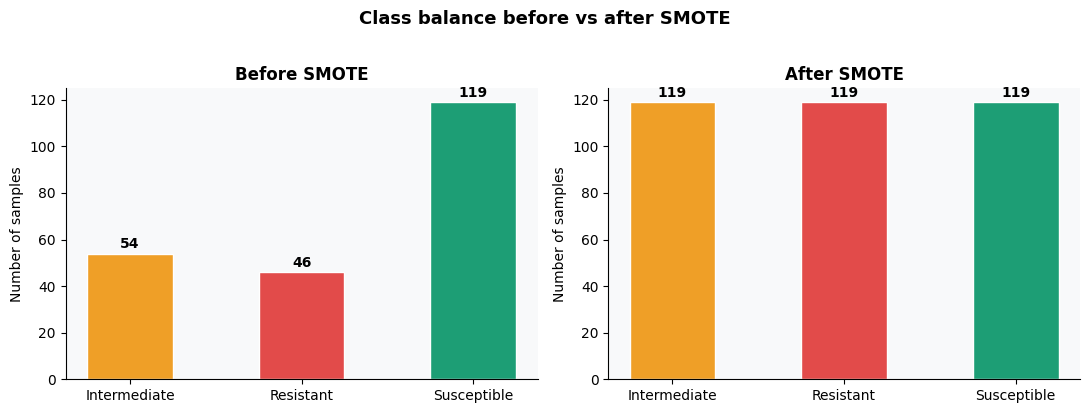

✓ Saved → figures/fig5_smote_balance.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

PALETTE = {
    'Resistant':    '#E24B4A',
    'Susceptible':  '#1D9E75',
    'Intermediate': '#EF9F27',
}
colors = [PALETTE[c] for c in le.classes_]

# Before SMOTE
before_counts = [( y_train == i).sum() for i in range(len(le.classes_))]
bars1 = ax1.bar(le.classes_, before_counts, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars1, before_counts):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, str(val),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Before SMOTE', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of samples')
ax1.set_facecolor('#f8f9fa')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# After SMOTE
after_counts = [(y_train_resampled == i).sum() for i in range(len(le.classes_))]
bars2 = ax2.bar(le.classes_, after_counts, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, after_counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, str(val),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('After SMOTE', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of samples')
ax2.set_facecolor('#f8f9fa')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Class balance before vs after SMOTE', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig5_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → figures/fig5_smote_balance.png")

In [10]:
# Save all preprocessed data for Notebook 3
save_path = MODELS_DIR / 'preprocessed_data.pkl'

with open(save_path, 'wb') as f:
    pickle.dump({
        'X_train': X_train_resampled,
        'X_test':  X_test,
        'y_train': y_train_resampled,
        'y_test':  y_test,
    }, f)

# Save label encoder
with open(MODELS_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save feature columns
with open(MODELS_DIR / 'feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print(f"✓ All files saved to: {MODELS_DIR}")
print(f"\nFiles in models folder:")
for f in sorted(MODELS_DIR.iterdir()):
    size = f.stat().st_size
    print(f"  {f.name} ({size} bytes)")

print(f"\nReady for Notebook 3 — Model Training")
print(f"  Training samples : {X_train_resampled.shape[0]}")
print(f"  Test samples     : {X_test.shape[0]}")
print(f"  Features         : {X_train_resampled.shape[1]}")

✓ All files saved to: C:\Users\raghu\track_b_amr\models

Files in models folder:
  best_model.pkl (4075793 bytes)
  feature_columns.pkl (431 bytes)
  label_encoder.pkl (284 bytes)
  preprocessed_data.pkl (69055 bytes)

Ready for Notebook 3 — Model Training
  Training samples : 357
  Test samples     : 55
  Features         : 19


---
## Key Findings — Preprocessing Summary

### Data Cleaning
- **Total isolates:** 274 real bacterial isolates from Mendeley dataset
- **Duplicates:** 0 removed (all isolates are genuine unique samples)
- **Missing values:** 0 found — dataset is complete
- **mm values converted:** Zone of inhibition → R/S/I using CLSI breakpoints

---

### Target Selection
- **Target antibiotic:** GENTAMICIN
- **Reason:** Most balanced class distribution
  - Susceptible: 149 (54%)
  - Intermediate: 68 (25%)
  - Resistant: 57 (21%)
- **Better than CIPROFLOXACIN** which had only 29 Susceptible (11%) — too imbalanced

---

### Feature Engineering
- **Original columns:** 6 (Location + 5 antibiotics)
- **After splitting Location:** Added City (IFE/OSU/IWO/EDE) + Source (T/C/S)
- **After one-hot encoding:** 19 features total
- **Features used:** IMIPENEM, CEFTAZIDIME, AUGMENTIN, CIPROFLOXACIN (R/S/I) + City + Source

---

### Train / Test Split
- **Training set:** 219 isolates (80%)
- **Test set:** 55 isolates (20%)
- **Stratified split:** Same class ratio maintained in both sets

---

### SMOTE Balancing
- **Before SMOTE:** Susceptible 119, Intermediate 47, Resistant 39 (imbalanced)
- **After SMOTE:** All 3 classes balanced to 119 samples each
- **Total training samples after SMOTE:** 357
- **Applied to training set only** — test set untouched

---

### Files Saved
- `preprocessed_data.pkl` — X_train, X_test, y_train, y_test
- `label_encoder.pkl` — converts 0/1/2 back to R/S/I labels
- `feature_columns.pkl` — 19 feature column names


